# Operational Screening of Wine Bottling Lots (Red + White)
*MLN601 Assessment 2 - Decision Tree Classification and CRISP-DM*

Design and Creative Technologies, Torrens University

| Field | Value |
|---|---|
| Student | Luis Guilherme de Barros Andrade Faria - A00187785 |
| Subject | MLN601 Machine Learning |
| Assessment | Assessment 2 - Classification |
| Operational case | Quality-control screening of production/bottling lots before release |
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Target | Low (`quality < 6`) = 1; high (`quality >= 6`) = 0 |
| Required algorithm | Decision Tree - default, AUC-tuned and balanced variants |
| Sensitivity studies | Leakage-safe SMOTE and kernel SVM benchmark |
| Methodology | CRISP-DM |
| Report body | Approximately 1,500 words, excluding title, code, references, declarations and glossary appendix |

This notebook treats each UCI observation as a **proxy for one representative laboratory sample
from a homogeneous bottling lot**, not as an individual bottle. The proposed system routes lots
at higher risk of low sensory quality to additional tasting or testing. It supports quality-control
staff; it never releases or rejects a lot automatically.

## 1. Business Understanding

A wine producer needs to release bottling lots efficiently without allowing weak batches to reach
distribution. The business question is: **can routine physicochemical measurements from a
representative sample identify lots at risk of low sensory quality before release?** Following the
brief, `quality < 6` is low (class 1) and triggers additional review; `quality >= 6` is high (class 0).

Operationally, a false negative is more costly: a weak lot continues through normal release. A
false positive places an acceptable lot on hold for an extra tasting, retest or investigation.
The model is therefore a triage layer between laboratory testing and the human release decision.

Laboratory testing and expert tasting already exist in the current process; the proposed improvement
is consistent routing. Routine lots continue through the standard path, while higher-risk lots enter
an intensive review queue. This does not promise fewer total tests. It focuses scarce attention and
makes hold decisions more repeatable and traceable.

Success is defined **before modelling**. In five-fold cross-validation (CV), the training data is
divided into five parts: the model trains on four and validates on the fifth, rotating until every
part has been used for validation. A candidate must
achieve ROC-AUC >= 0.75, low-quality sensitivity >= 0.70 and high-quality specificity >= 0.70,
with zero duplicate overlap across the held-out boundary. Among candidates passing every gate,
priority goes to sensitivity, then balanced accuracy, interpretability and simplicity. These are
screening targets for this assessment, not validated production service levels.

## 2. Data Understanding

### 2.1 Data acquisition and operational unit

| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository - Wine Quality (id 186) |
| Link | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Files | `winequality-red.csv` and `winequality-white.csv` |
| Acquisition | Local UCI copies with direct-URL fallback |
| Raw rows | 1,599 red + 4,898 white = 6,497 |
| Operational interpretation | One row is a proxy for one representative lot sample |

The source contains physicochemical tests and an expert sensory score for Portuguese *vinho verde*
(Cortez et al., 2009). It has no `batch_id`, production date or release decision; consequently,
performance here demonstrates technical feasibility, not proven lot-level safety or return on
investment. Red and white files are combined with `wine_type` (red = 1, white = 0).

### 2.2 Variables

| Variable group | Type and units | Role |
|---|---|---|
| Fixed, volatile and citric acidity; residual sugar; chlorides; sulphates | Continuous, g/dm3 | Laboratory predictors |
| Free and total sulfur dioxide | Continuous, mg/dm3 | Laboratory predictors |
| Density | Continuous, g/cm3 | Laboratory predictor |
| pH | Continuous, pH scale | Laboratory predictor |
| Alcohol | Continuous, % volume | Laboratory predictor |
| `wine_type` | Engineered binary | Red/white context |
| `quality` | Ordinal integer, source score 0-10 | Source target, excluded from predictors |
| `quality_label` | Engineered binary | Model target: low = 1, high = 0 |

In [1]:
import os
import sys
import warnings
from importlib.metadata import version as package_version

os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, balanced_accuracy_score,
                             make_scorer)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as exc:
    raise ImportError(
        "Install the Assessment2 requirements first: "
        "python -m pip install -r requirements.txt"
    ) from exc

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

runtime = {
    "Python": sys.version.split()[0],
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "scikit-learn": package_version("scikit-learn"),
    "imbalanced-learn": package_version("imbalanced-learn"),
}
pd.Series(runtime, name="version").to_frame()

,version
Python,3.14.3
numpy,2.5.0
pandas,3.0.3
scikit-learn,1.9.0
imbalanced-learn,0.14.2


In [2]:
from pathlib import Path

# Resolve folders whether execution starts from notebook/ or the assessment root.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = "winequality-%s.csv" % colour
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        print("Loading local dataset:", local.name)
        return pd.read_csv(local, sep=";")
    print("Loading UCI dataset:", fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1
white["wine_type"] = 0
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local dataset: winequality-red.csv
Loading local dataset: winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
source_features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol",
]
expected_columns = source_features + ["quality", "wine_type"]
numeric_values = df[expected_columns].to_numpy()
duplicate_rows = int(df.duplicated().sum())

hard_checks = {
    "Expected schema": list(df.columns) == expected_columns,
    "All columns numeric": all(pd.api.types.is_numeric_dtype(df[c]) for c in expected_columns),
    "No missing values": int(df.isna().sum().sum()) == 0,
    "All values finite": bool(np.isfinite(numeric_values).all()),
    "No negative laboratory values": bool((df[source_features].to_numpy() >= 0).all()),
    "Quality is integer-valued": bool(np.allclose(df["quality"], df["quality"].astype(int))),
    "Quality within documented 0-10 range": bool(df["quality"].between(0, 10).all()),
    "Free SO2 does not exceed total SO2": bool(
        (df["free sulfur dioxide"] <= df["total sulfur dioxide"]).all()
    ),
}
assert all(hard_checks.values()), "A hard data-quality validation failed"

validation_rows = [
    {"check": name, "status": "Pass" if passed else "Fail", "action": "Retain"}
    for name, passed in hard_checks.items()
]
validation_rows.append({
    "check": "Exact duplicate source rows",
    "status": "Issue found: %d" % duplicate_rows,
    "action": "Remove before target engineering and splitting",
})
validation_rows.append({
    "check": "Observed quality levels",
    "status": ", ".join(map(str, sorted(df["quality"].unique()))),
    "action": "Retain; levels are inside documented range",
})
data_quality = pd.DataFrame(validation_rows)
data_quality.to_csv(OUTPUT_DIR / "data_quality_v5.csv", index=False)

print("Raw rows:", len(df), "| exact duplicates:", duplicate_rows)
display(data_quality)

Raw rows: 6497 | exact duplicates: 1177


,check,status,action
0,Expected schema,Pass,Retain
1,All columns numeric,Pass,Retain
2,No missing values,Pass,Retain
3,All values finite,Pass,Retain
4,No negative laboratory values,Pass,Retain
5,Quality is integer-valued,Pass,Retain
6,Quality within documented 0-10 range,Pass,Retain
7,Free SO2 does not exceed total SO2,Pass,Retain
8,Exact duplicate source rows,Issue found: 1177,Remove before target engineering and splitting
9,Observed quality levels,"3, 4, 5, 6, 7, 8, 9",Retain; levels are inside documented range


### 2.3 Target and duplicate issue

The brief's threshold creates `quality < 6 -> low (1)` and `quality >= 6 -> high (0)`. Low is
positive because it is the event that places a lot on review. The audit finds 1,177 exact rows.
Because UCI provides no sample or lot identifiers, these might include genuinely separate samples
with identical recorded values. Removal is nevertheless a conservative evaluation choice: it
prevents an identical feature/label record appearing in both training and test data. The resulting
population has 5,320 unique proxy samples and moderate 62.6/37.4 class imbalance.

Raw rows: 6497 | duplicates removed: 1177 | unique rows: 5320

Class counts:
quality_label
high (>=6)    3332
low (<6)      1988

Class proportions:
quality_label
high (>=6)    0.626
low (<6)      0.374


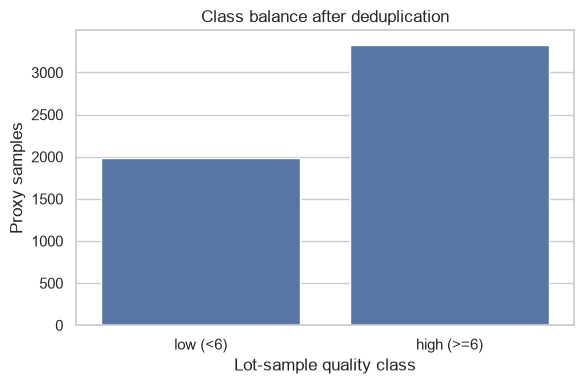

In [6]:
raw_rows = len(df)
duplicate_rows = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

df["quality_label"] = (df["quality"] < 6).astype(int)
label_names = {0: "high (>=6)", 1: "low (<6)"}
df["quality_name"] = df["quality_label"].map(label_names)

counts = df["quality_label"].value_counts().sort_index()
print("Raw rows:", raw_rows,
      "| duplicates removed:", duplicate_rows,
      "| unique rows:", len(df))
print("\nClass counts:")
print(counts.rename(index=label_names).to_string())
print("\nClass proportions:")
print((counts / len(df)).round(3).rename(index=label_names).to_string())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_name", data=df, order=["low (<6)", "high (>=6)"])
plt.title("Class balance after deduplication")
plt.xlabel("Lot-sample quality class")
plt.ylabel("Proxy samples")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_class_balance.png", dpi=120)
plt.show()

### 2.4 Relationships with the target

The heatmap checks relationships among laboratory measurements; the required seaborn pairplot
shows class overlap. A separate target-correlation ranking uses `quality_label`, where positive
values indicate association with **low** quality. Correlation is univariate association, not
causation or model importance; the tree may assign importance differently through interactions.

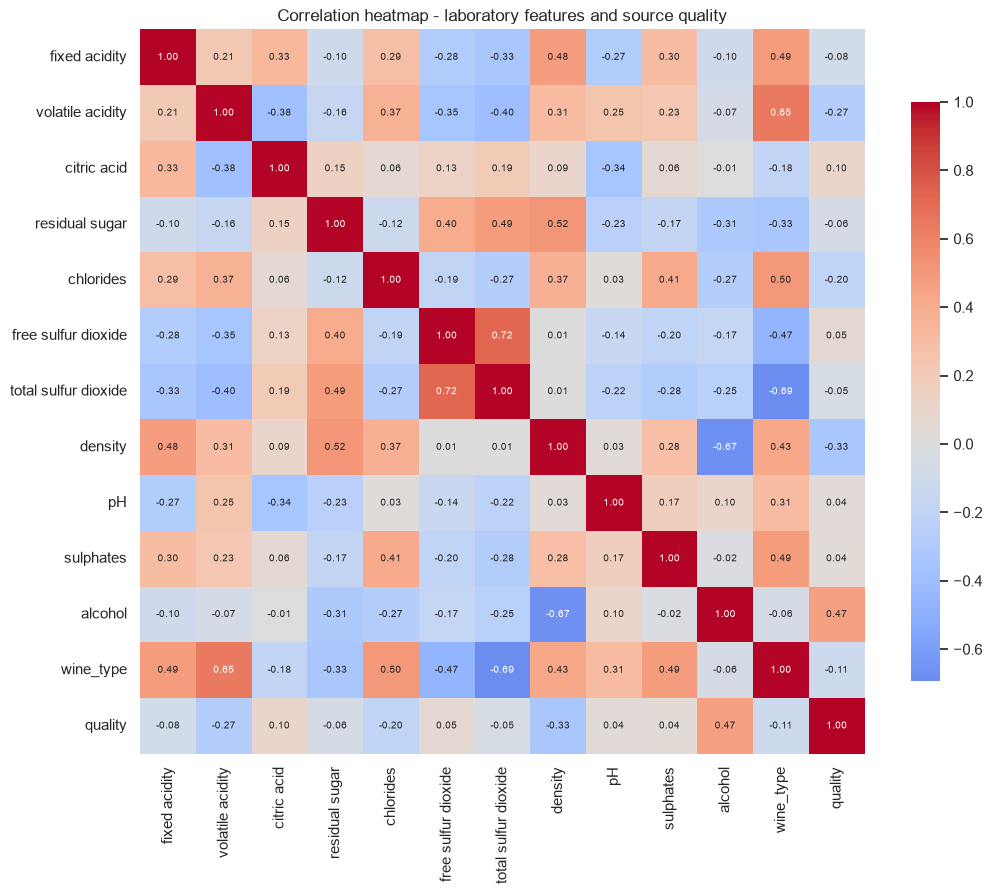

,correlation_with_low_quality
alcohol,-0.4145
density,0.2872
volatile acidity,0.2699
chlorides,0.1874
wine_type,0.1177
citric acid,-0.0871
fixed acidity,0.0720
total sulfur dioxide,0.0494
residual sugar,0.0478
free sulfur dioxide,-0.0468


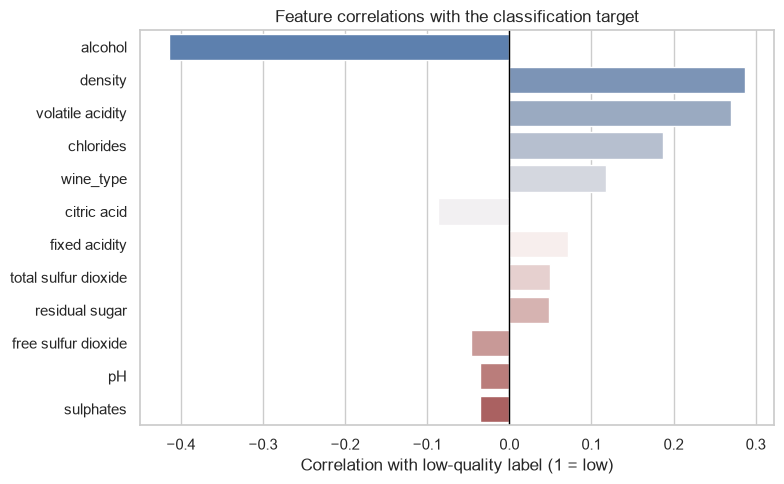

In [7]:
heatmap_columns = source_features + ["wine_type", "quality"]
source_corr = df[heatmap_columns].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(source_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap - laboratory features and source quality")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_corr_heatmap.png", dpi=120)
plt.show()

target_corr = (df[source_features + ["wine_type", "quality_label"]]
               .corr()["quality_label"].drop("quality_label"))
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
target_corr.rename("correlation_with_low_quality").to_csv(
    OUTPUT_DIR / "target_correlations_v5.csv", header=True)
display(target_corr.rename("correlation_with_low_quality").round(4).to_frame())

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with low-quality label (1 = low)")
plt.ylabel("")
plt.title("Feature correlations with the classification target")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_target_correlations.png", dpi=120)
plt.show()

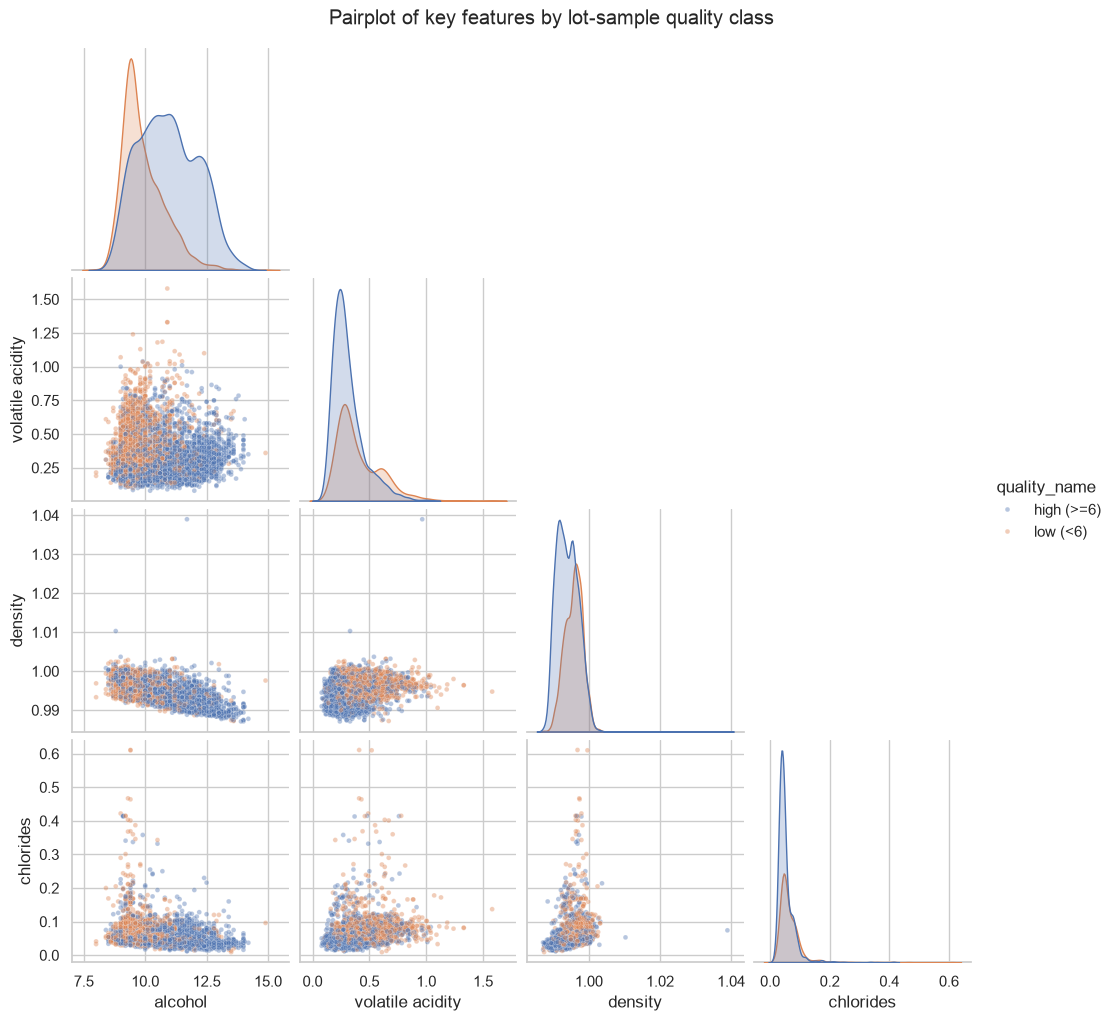

In [8]:
pair_cols = ["alcohol", "volatile acidity", "density", "chlorides"]
g = sns.pairplot(df, vars=pair_cols, hue="quality_name",
                 hue_order=["high (>=6)", "low (<6)"], corner=True,
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde")
g.fig.suptitle("Pairplot of key features by lot-sample quality class", y=1.02)
g.savefig(FIG_DIR / "v5_pairplot.png", dpi=110)
plt.show()

**Interpretation.** The validation checks pass for schema, types, missing/non-finite values and
physical consistency; exact duplication is the documented quality issue. `alcohol` has the
strongest target association (-0.4145): more alcohol is associated with a lower probability of the
positive low-quality class. `density` (+0.2872) and `volatile acidity` (+0.2699) have the strongest
positive associations with low quality. The pairplot still shows substantial overlap, so near-perfect
lot screening is unrealistic. Later, tree importance again identifies alcohol as the strongest
predictor, but importance reflects learned splits rather than a standalone linear relationship.

## 3. Data Preparation

Preparation uses four safeguards. First, exact source rows are removed before target engineering
and splitting. Second, source `quality` and derived labels are excluded from predictors while
`wine_type` remains. Third, an 80/20 stratified split preserves the class ratio and is checked for
zero exact overlap. Fourth, scaling and SMOTE stay inside pipelines, so each validation fold learns
preprocessing from its own training portion only (Chawla et al., 2002; Pedregosa et al., 2011).

Two additional attributes are tested on training data: bound SO2 (`total - free`) and the free-SO2
ratio (`free / total`). They are retained only if AUC or balanced accuracy improves by at least 0.01
without materially weakening sensitivity or specificity. This makes feature engineering an
evidence-based experiment rather than an automatic increase in model complexity.

In [9]:
LEAK_COLS = ["quality", "quality_label", "quality_name"]
feature_cols = [c for c in df.columns if c not in LEAK_COLS]
X = df[feature_cols]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

train_keys = pd.MultiIndex.from_frame(X_train)
test_keys = pd.MultiIndex.from_frame(X_test)
overlap_count = int(test_keys.isin(train_keys).sum())
assert overlap_count == 0, "Exact feature rows leaked across train/test split"
assert set(LEAK_COLS).isdisjoint(X.columns), "Target-derived field entered predictors"

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Exact train/test feature overlap:", overlap_count)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("\nFeatures used (%d):" % len(feature_cols), feature_cols)

Train: (4256, 12) | Test: (1064, 12)
Exact train/test feature overlap: 0

Train class balance:
quality_label
high (>=6)    0.626
low (<6)      0.374
Test class balance:
quality_label
high (>=6)    0.626
low (<6)      0.374

Features used (12): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']


## 4. Modelling

The required Decision Tree is the main experiment. A majority baseline establishes the no-skill
floor; the default tree exposes overfitting; five-fold `GridSearchCV` then tunes criterion, depth and
minimum leaf size for ROC-AUC. The balanced tree freezes that structure and changes only error cost,
while SMOTE tests synthetic minority examples inside training folds. An SVM kernel search is retained
as a technical ranking benchmark, not as the operational recommendation.

Selection is made from training cross-validation before final test evaluation. The approval gates
are AUC >= 0.75, low-quality sensitivity >= 0.70 and high-quality specificity >= 0.70. This prevents
the held-out test set from becoming a model-selection tool.

In [10]:
# 1) Majority baseline and default Decision Tree.
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# 2) Required Decision Tree tuned on training folds for the brief's ROC-AUC metric.
tree_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid, scoring="roc_auc", cv=5, n_jobs=1)
grid.fit(X_train, y_train)
dt_auc = grid.best_estimator_

tree_structure = {
    "criterion": grid.best_params_["criterion"],
    "max_depth": grid.best_params_["max_depth"],
    "min_samples_leaf": grid.best_params_["min_samples_leaf"],
}

# 3) Same structure, balanced class costs.
dt_balanced = DecisionTreeClassifier(
    **tree_structure, class_weight="balanced", random_state=RANDOM_STATE)
dt_balanced.fit(X_train, y_train)

# 4) Same structure, synthetic minority samples produced inside each fold.
smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("tree", DecisionTreeClassifier(**tree_structure, random_state=RANDOM_STATE)),
])
smote_grid = GridSearchCV(
    smote_pipe,
    {"smote__k_neighbors": [3, 5, 7]},
    scoring="balanced_accuracy", cv=5, n_jobs=1)
smote_grid.fit(X_train, y_train)
dt_smote = smote_grid.best_estimator_

# 5) Kernel SVM technical benchmark; scaling remains fold-local.
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC()),
])
svm_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"]},
    {"svc__kernel": ["poly"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"], "svc__degree": [2, 3]},
    {"svc__kernel": ["sigmoid"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"]},
]
svm_search = GridSearchCV(
    svm_pipe, svm_grid, scoring="roc_auc", cv=5, n_jobs=1,
    return_train_score=False)
svm_search.fit(X_train, y_train)
svm_best = svm_search.best_estimator_

models = {
    "Majority baseline": dummy,
    "Decision Tree (default)": dt_default,
    "Decision Tree (AUC-tuned)": dt_auc,
    "Decision Tree (balanced)": dt_balanced,
    "Decision Tree (SMOTE)": dt_smote,
    "SVM (best kernel)": svm_best,
}

print("Tree best params:", grid.best_params_)
print("Tree best CV ROC-AUC: %.3f" % grid.best_score_)
print("SMOTE best params:", smote_grid.best_params_)
print("SVM best params:", svm_search.best_params_)

Tree best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20}
Tree best CV ROC-AUC: 0.791
SMOTE best params: {'smote__k_neighbors': 5}
SVM best params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


### 4.1 Training-only selection and feature ablation

The following cell records tuning results, evaluates every candidate against the predeclared gates
using the same five-fold training procedure, and tests the two sulfur features. The final test set
remains untouched until Section 5.

In [11]:
best_params = pd.Series(grid.best_params_, dtype="object").astype(str)
best_params.loc["cv_roc_auc"] = round(grid.best_score_, 4)
best_params.to_csv(OUTPUT_DIR / "tree_best_params_v5.csv", header=["value"])

smote_results = (pd.DataFrame(smote_grid.cv_results_)
                 [["param_smote__k_neighbors", "mean_test_score", "std_test_score", "rank_test_score"]]
                 .sort_values("rank_test_score"))
smote_results.to_csv(OUTPUT_DIR / "smote_results_v5.csv", index=False)

svm_cv = pd.DataFrame(svm_search.cv_results_)
svm_kernel_results = (svm_cv.assign(kernel=svm_cv["param_svc__kernel"].astype(str))
                      .groupby("kernel", as_index=False)["mean_test_score"].max()
                      .rename(columns={"mean_test_score": "best_cv_roc_auc"})
                      .sort_values("best_cv_roc_auc", ascending=False))
svm_kernel_results.to_csv(OUTPUT_DIR / "svm_kernel_results_v5.csv", index=False)

cv_scoring = {
    "roc_auc": "roc_auc",
    "sensitivity_low": make_scorer(recall_score, pos_label=1),
    "specificity_high": make_scorer(recall_score, pos_label=0),
    "balanced_accuracy": "balanced_accuracy",
    "f1_low": "f1",
}
cv_candidates = {
    "AUC-tuned tree": dt_auc,
    "Balanced tree": dt_balanced,
    "SMOTE tree": dt_smote,
    "RBF SVM": svm_best,
}
cv_rows = []
for model_name, candidate in cv_candidates.items():
    scores = cross_validate(candidate, X_train, y_train, cv=5,
                            scoring=cv_scoring, n_jobs=1)
    row = {"model": model_name}
    for metric in cv_scoring:
        row[metric] = scores["test_" + metric].mean()
        row[metric + "_std"] = scores["test_" + metric].std()
    cv_rows.append(row)

cv_comparison = pd.DataFrame(cv_rows).set_index("model")
cv_comparison["passes_auc"] = cv_comparison["roc_auc"] >= 0.75
cv_comparison["passes_sensitivity"] = cv_comparison["sensitivity_low"] >= 0.70
cv_comparison["passes_specificity"] = cv_comparison["specificity_high"] >= 0.70
cv_comparison["passes_all_gates"] = cv_comparison[
    ["passes_auc", "passes_sensitivity", "passes_specificity"]
].all(axis=1)
cv_comparison.to_csv(OUTPUT_DIR / "candidate_cv_metrics_v5.csv")

# Training-only feature-engineering ablation.
def add_sulfur_features(frame):
    result = frame.copy()
    result["bound_sulfur_dioxide"] = (
        result["total sulfur dioxide"] - result["free sulfur dioxide"]
    )
    result["free_so2_ratio"] = (
        result["free sulfur dioxide"] / result["total sulfur dioxide"]
    )
    return result

X_train_engineered = add_sulfur_features(X_train)
engineered_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid, scoring="roc_auc", cv=5, n_jobs=1)
engineered_grid.fit(X_train_engineered, y_train)
engineered_structure = {
    "criterion": engineered_grid.best_params_["criterion"],
    "max_depth": engineered_grid.best_params_["max_depth"],
    "min_samples_leaf": engineered_grid.best_params_["min_samples_leaf"],
}
engineered_balanced = DecisionTreeClassifier(
    **engineered_structure, class_weight="balanced", random_state=RANDOM_STATE)
engineered_scores = cross_validate(
    engineered_balanced, X_train_engineered, y_train, cv=5,
    scoring=cv_scoring, n_jobs=1)

base_balanced = cv_comparison.loc["Balanced tree"]
ablation = pd.DataFrame([
    {
        "feature_set": "Base 12 features",
        "tuned_cv_auc": grid.best_score_,
        "balanced_tree_cv_auc": base_balanced["roc_auc"],
        "sensitivity_low": base_balanced["sensitivity_low"],
        "specificity_high": base_balanced["specificity_high"],
        "balanced_accuracy": base_balanced["balanced_accuracy"],
        "retained": True,
    },
    {
        "feature_set": "Base + bound SO2 + free SO2 ratio",
        "tuned_cv_auc": engineered_grid.best_score_,
        "balanced_tree_cv_auc": engineered_scores["test_roc_auc"].mean(),
        "sensitivity_low": engineered_scores["test_sensitivity_low"].mean(),
        "specificity_high": engineered_scores["test_specificity_high"].mean(),
        "balanced_accuracy": engineered_scores["test_balanced_accuracy"].mean(),
        "retained": False,
    },
])
ablation.to_csv(OUTPUT_DIR / "feature_ablation_v5.csv", index=False)

display(best_params.to_frame("value"))
cv_display = (cv_comparison[["roc_auc", "sensitivity_low", "specificity_high",
                             "balanced_accuracy", "passes_all_gates"]]
              .rename(columns={"roc_auc": "AUC",
                               "sensitivity_low": "Sensitivity",
                               "specificity_high": "Specificity",
                               "balanced_accuracy": "Balanced acc.",
                               "passes_all_gates": "Pass"}))
ablation_display = (ablation[["feature_set", "tuned_cv_auc",
                              "balanced_accuracy", "retained"]]
                    .rename(columns={"feature_set": "Feature set",
                                     "tuned_cv_auc": "Tuned AUC",
                                     "balanced_accuracy": "Balanced acc.",
                                     "retained": "Retain"})
                    .set_index("Feature set"))
display(cv_display.round(3))
display(ablation_display.round(3))
display(svm_kernel_results.round(4))

,value
criterion,gini
max_depth,5
min_samples_leaf,20
cv_roc_auc,0.791


,AUC,Sensitivity,Specificity,Balanced acc.,Pass
model,,,,,
AUC-tuned tree,0.791,0.643,0.787,0.715,False
Balanced tree,0.787,0.731,0.703,0.717,True
SMOTE tree,0.783,0.738,0.696,0.717,False
RBF SVM,0.826,0.631,0.843,0.737,False


,Tuned AUC,Balanced acc.,Retain
Feature set,,,
Base 12 features,0.791,0.717,True
Base + bound SO2 + free SO2 ratio,0.789,0.724,False


,kernel,best_cv_roc_auc
2,rbf,0.8265
0,linear,0.8043
1,poly,0.7950
3,sigmoid,0.7027


## 5. Evaluation

The held-out test now confirms the frozen selection. ROC-AUC measures ranking across thresholds;
sensitivity measures the share of genuinely low proxy lots caught; specificity measures the share
of genuinely high proxy lots cleared. Precision, F1, balanced accuracy and G-mean expose the cost
of favouring one class. In the confusion matrix, FN is a weak lot missed and FP is an acceptable lot
sent to unnecessary review.

In [12]:
def model_scores(model, X_te):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_te)[:, 1]
    return model.decision_function(X_te)


def class_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    score = model_scores(model, X_te)
    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
    sensitivity = recall_score(y_te, pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "accuracy": accuracy_score(y_te, pred),
        "precision_low": precision_score(y_te, pred, pos_label=1, zero_division=0),
        "sensitivity_low": sensitivity,
        "specificity_high": specificity,
        "f1_low": f1_score(y_te, pred, pos_label=1, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred),
        "g_mean": np.sqrt(sensitivity * specificity),
        "roc_auc": roc_auc_score(y_te, score),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


results_full = pd.DataFrame(
    {name: class_metrics(model, X_test, y_test) for name, model in models.items()}
).T
results_full.index.name = "model"
results_full.to_csv(OUTPUT_DIR / "model_metrics_v5.csv")

metric_cols = ["accuracy", "precision_low", "sensitivity_low", "specificity_high",
               "f1_low", "balanced_accuracy", "g_mean", "roc_auc"]
results_full[metric_cols].round(3)

,accuracy,precision_low,sensitivity_low,specificity_high,f1_low,balanced_accuracy,g_mean,roc_auc
model,,,,,,,,
Majority baseline,0.626,0.000,0.000,1.000,0.000,0.500,0.000,0.500
Decision Tree (default),0.682,0.579,0.555,0.758,0.567,0.657,0.649,0.657
Decision Tree (AUC-tuned),0.739,0.672,0.588,0.829,0.627,0.708,0.698,0.793
Decision Tree (balanced),0.728,0.615,0.734,0.725,0.669,0.729,0.729,0.792
Decision Tree (SMOTE),0.733,0.627,0.709,0.748,0.665,0.728,0.728,0.787
SVM (best kernel),0.762,0.723,0.590,0.865,0.650,0.728,0.715,0.824


In [13]:
report = classification_report(
    y_test, dt_balanced.predict(X_test),
    target_names=["high (>=6)", "low (<6)"],
    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(3)
report_df.to_csv(OUTPUT_DIR / "classification_report_v5.csv")
report_df

,precision,recall,f1-score,support
high (>=6),0.820,0.725,0.770,666.000
low (<6),0.615,0.734,0.669,398.000
accuracy,0.728,0.728,0.728,0.728
macro avg,0.717,0.729,0.719,1064.000
weighted avg,0.743,0.728,0.732,1064.000


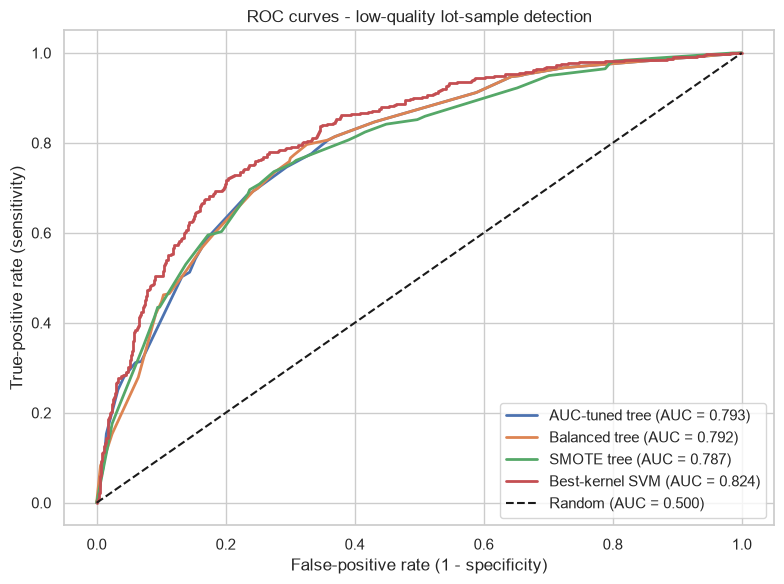

In [14]:
roc_models = {
    "AUC-tuned tree": dt_auc,
    "Balanced tree": dt_balanced,
    "SMOTE tree": dt_smote,
    "Best-kernel SVM": svm_best,
}

plt.figure(figsize=(8, 6))
for name, model in roc_models.items():
    score = model_scores(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, score, pos_label=1)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, linewidth=2, label="%s (AUC = %.3f)" % (name, auc))
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False-positive rate (1 - specificity)")
plt.ylabel("True-positive rate (sensitivity)")
plt.title("ROC curves - low-quality lot-sample detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_roc_curves.png", dpi=120)
plt.show()

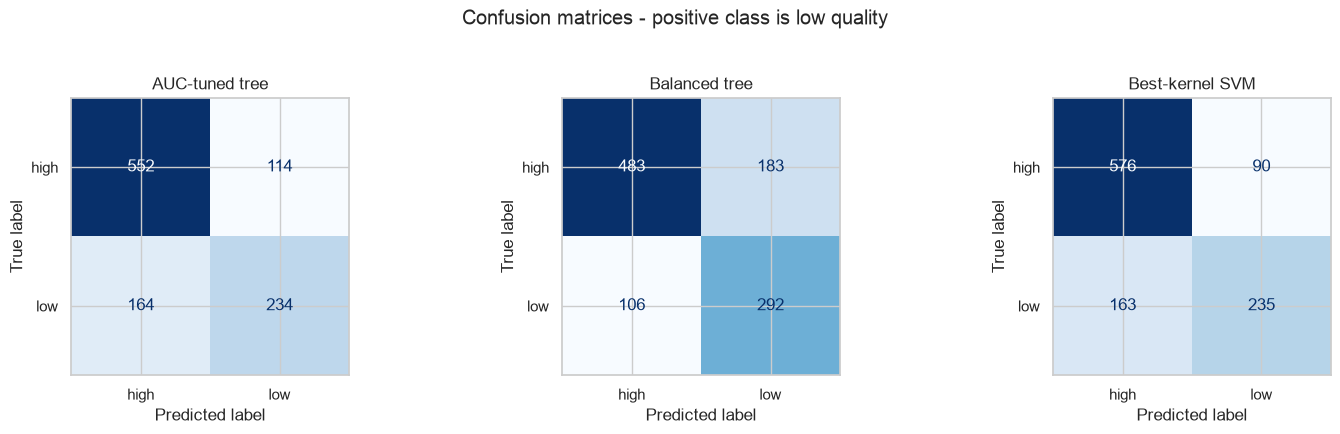

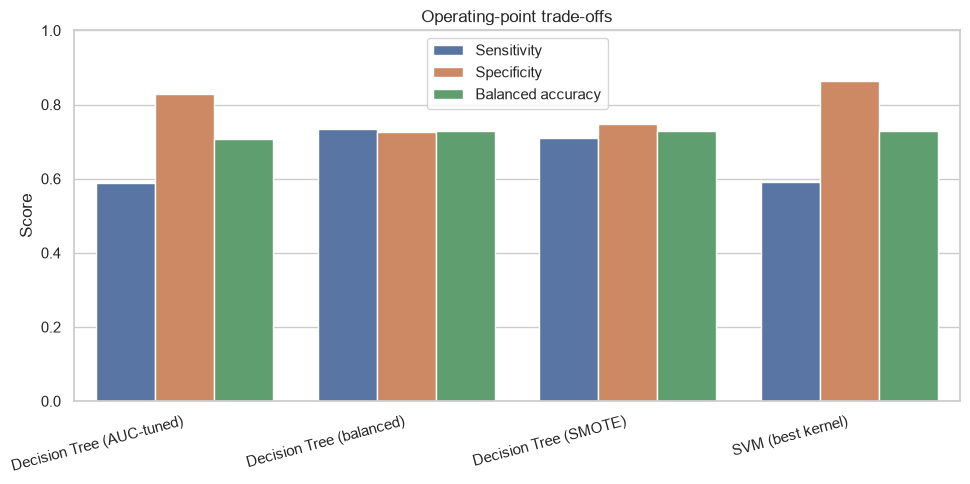

In [15]:
comparison_models = {
    "AUC-tuned tree": dt_auc,
    "Balanced tree": dt_balanced,
    "Best-kernel SVM": svm_best,
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, model) in zip(axes, comparison_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["high", "low"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
fig.suptitle("Confusion matrices - positive class is low quality", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

balance_plot = (results_full.loc[["Decision Tree (AUC-tuned)",
                                  "Decision Tree (balanced)",
                                  "Decision Tree (SMOTE)",
                                  "SVM (best kernel)"],
                                 ["sensitivity_low", "specificity_high", "balanced_accuracy"]]
                .rename(columns={"sensitivity_low": "Sensitivity",
                                 "specificity_high": "Specificity",
                                 "balanced_accuracy": "Balanced accuracy"})
                .reset_index().melt(id_vars="model", var_name="metric", value_name="score"))
plt.figure(figsize=(10, 5))
sns.barplot(data=balance_plot, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Score")
plt.title("Operating-point trade-offs")
plt.xticks(rotation=15, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_operating_tradeoffs.png", dpi=120)
plt.show()

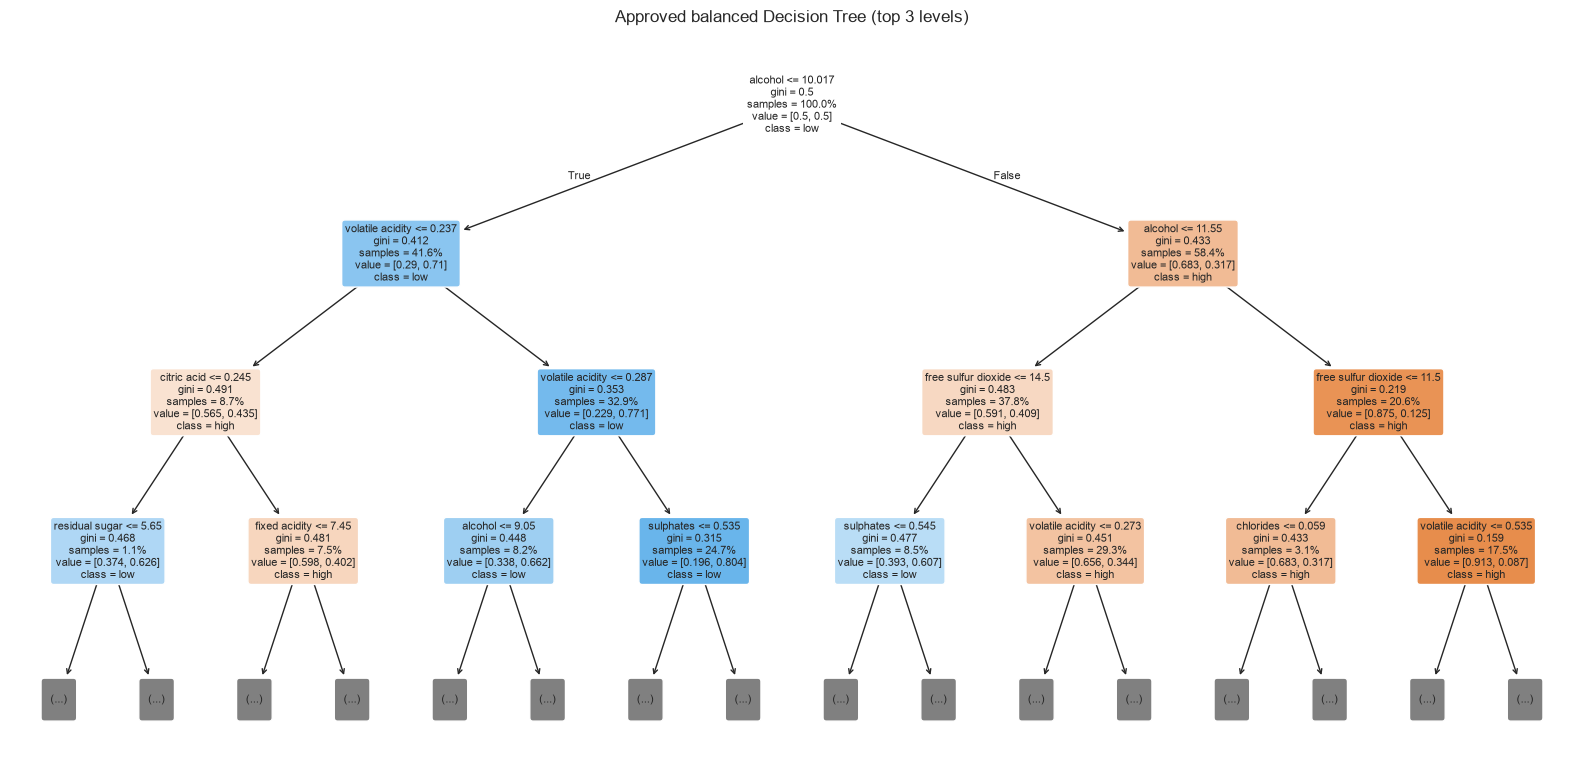

In [16]:
plt.figure(figsize=(16, 8))
plot_tree(dt_balanced, feature_names=feature_cols, class_names=["high", "low"],
          filled=True, rounded=True, max_depth=3, fontsize=8,
          impurity=True, proportion=True)
plt.title("Approved balanced Decision Tree (top 3 levels)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_decision_tree.png", dpi=110)
plt.show()

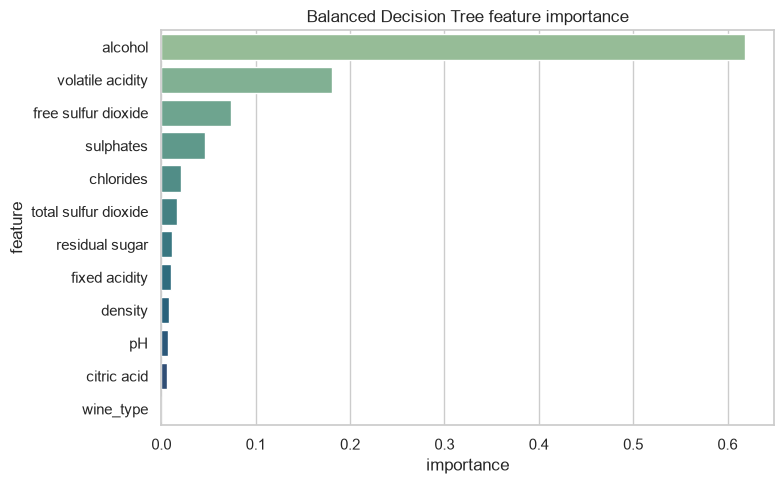

,feature,importance
0,alcohol,0.618359
1,volatile acidity,0.180513
2,free sulfur dioxide,0.073486
3,sulphates,0.046002
4,chlorides,0.020544
5,total sulfur dioxide,0.016899
6,residual sugar,0.011502
7,fixed acidity,0.010528
8,density,0.008234
9,pH,0.007513


In [17]:
importance = (pd.DataFrame({"feature": feature_cols,
                            "importance": dt_balanced.feature_importances_})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))
importance.to_csv(OUTPUT_DIR / "feature_importance_v5.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=importance,
            hue="feature", palette="crest", legend=False)
plt.title("Balanced Decision Tree feature importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "v5_feature_importance.png", dpi=120)
plt.show()
importance

### 5.1 Operational result

The Balanced Tree is the only candidate passing all training gates: CV AUC **0.787**, sensitivity
**0.731** and specificity **0.703**. The held-out test confirms AUC **0.792**, sensitivity **0.734**,
specificity **0.725**, balanced accuracy **0.729** and F1 **0.669**. It catches 292 of 398 genuinely
low proxy lots and misses 106; 183 acceptable proxy lots receive unnecessary review.

Relative to the AUC-tuned tree, balancing catches **58 additional weak lots** but creates **69
additional false alarms**. Operationally, this exchanges extra tasting and possible release delay
for fewer weak batches escaping normal quality control. The RBF SVM ranks best (AUC **0.824**) but
its default-threshold sensitivity is only **0.590**, so strong ranking alone does not satisfy the
screening objective. Alcohol has the highest tree importance (about **0.62**), consistent with its
leading target correlation, while volatile acidity is the next major split signal.

<div style="break-before: page;"></div>

### 5.2 Approval decision

| Candidate | Decision | Reason |
|---|---|---|
| Balanced Decision Tree | **Approve for controlled pilot** | Passes every CV gate, catches more weak lots and exposes inspectable rules |
| AUC-tuned Decision Tree | Do not approve for screening | Sensitivity is below 0.70 |
| SMOTE Decision Tree | Do not approve | CV specificity is below 0.70 and synthetic data adds complexity |
| RBF SVM | Benchmark only | Highest AUC, but sensitivity is below the operational gate |

Approval means human-supervised triage, not automated rejection or release. Threshold optimisation
is deferred until the producer supplies the cost of a missed weak lot, an unnecessary hold and an
additional tasting; choosing it now would invent a business cost function.

## 6. Deployment / Lessons Learned

The proposed pilot records `lot_id`, laboratory measurements, model version, risk score, screening
decision and timestamp. Flagged lots enter quality-control hold for tasting, retesting or process
investigation; staff retain final authority. Real validation also needs production date, tank or
line, wine type, tasting result and final release outcome because the UCI data has none of this
operational context.

Monitoring should track sensitivity, specificity, percentage of lots held, unnecessary reviews,
weak-lot escapes and release lead time, segmented by red and white wine. Validation must use a later
production period or independent producer before wider adoption.

During the pilot, a weekly review should reconcile model flags with tasting and release outcomes.
Every false-negative lot should trigger root-cause review; shifts in hold rate or class mix should
trigger a recalibration assessment. Rollback is simple: disable model routing and return every lot
to the existing manual workflow.

The main lessons are that data quality can change the evaluation, feature engineering must earn its
complexity, and the highest AUC is not automatically the best operating policy. Class weighting was
simpler than synthetic sampling and was the only candidate to pass all predefined screening gates.
The model therefore improves operational consistency by prioritising review, while its limitations
remain visible to the people responsible for release.

---

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Opus 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline,
improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "Explain why low-quality wine should be the positive class and how sensitivity, specificity, balanced accuracy and G-mean relate to its confusion matrix."
2. "Design a leakage-safe comparison between class weighting and SMOTE where synthetic samples are created only inside cross-validation training folds."
3. "Explain SVM margin, support vectors, C, gamma and the kernel trick, then propose a GridSearchCV comparison scored by ROC-AUC."

I confirm that the use of these tools has been in accordance with the Torrens University Australia
Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that
the final output is authored by me and represents my own critical thinking, analysis, and synthesis
of sources. I take full responsibility for the final content of this report.

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357. https://doi.org/10.1613/jair.953

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*, 273-297. https://doi.org/10.1007/BF00994018

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Domingos, P., & Pazzani, M. (1997). On the optimality of the simple Bayesian classifier under zero-one loss. *Machine Learning, 29*(2-3), 103-130. https://doi.org/10.1023/A:1007413511361

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Wine Quality* [Data set]. UCI Machine Learning Repository. Retrieved July 2, 2026, from https://archive.ics.uci.edu/dataset/186/wine+quality

## Appendix A - Glossary

| Term | Meaning in this assessment |
|---|---|
| Cross-validation (CV) | Repeated training validation using five folds of the training set; used to select models before the final test |
| Fold | One of the five training-data partitions used by CV |
| Held-out test set | Untouched 20% of the data used once to confirm the frozen model decision |
| ROC-AUC | Measures how well risk scores rank low-quality samples above high-quality samples across all thresholds |
| Sensitivity / recall | Share of genuinely low-quality proxy lots correctly flagged |
| Specificity | Share of genuinely high-quality proxy lots correctly cleared |
| Precision | Share of low-quality flags that are correct |
| Confusion matrix | Counts true/false positives and true/false negatives at one threshold |
| Threshold | Score boundary that converts model risk into flag or clear |
| Class imbalance | Unequal class frequency; 37.4% low versus 62.6% high after deduplication |
| Hyperparameter | Model setting chosen before fitting, such as tree depth or minimum leaf size |
| GridSearchCV | Tests hyperparameter combinations using cross-validation |
| Class weighting | Makes mistakes on the minority low-quality class more costly during tree fitting |
| SMOTE | Creates synthetic minority examples inside training folds |
| SVM / RBF kernel | Benchmark model that searches for a separating boundary, allowing nonlinear shape with RBF |
| Leakage | Information from validation/test data entering training and making results look unrealistically strong |
| Feature engineering | Deriving candidate predictors from source variables and retaining them only when evidence supports it |
| Correlation | Univariate linear association; it does not establish causation |
| Feature importance | Tree-based measure of how much a feature contributes to impurity-reducing splits |
| Proxy lot sample | UCI observation interpreted as a representative lot sample; not a real recorded batch ID |
| Human-supervised pilot | Model routes review, while quality-control staff retain release authority |